In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import os
import shlex
import sys
from joblib import load
import glob 
import re


## loss and accuracy

In [2]:
res_dirs = "results_min7_max7_pairs_v1/logpolar"
res_files = glob.glob(os.path.join(res_dirs, "results_*.pkl"))
res_files

['results_min7_max7_pairs_v1/logpolar/results_rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl']

In [3]:
res_lists = {}
shortmodelnames = dict(zip(res_files,
                           ["one-hot"]))
for rf,sn in shortmodelnames.items():
    res = load(rf)
    res_lists[sn] = res
        
    
# we have 300+1 epochs in total
loss_cols = ['count map loss','count num loss','dist map loss']
acc_cols = ['accuracy count']

res.columns

Index(['full map loss', 'dist map loss', 'count map loss', 'count num loss',
       'dist num loss', 'all num loss', 'shape loss', 'accuracy count',
       'accuracy dist', 'accuracy all', 'epoch', 'dataset', 'accuracy map',
       'viewing', 'test shapes', 'test lums'],
      dtype='object')

In [4]:
list(res_lists.keys())

['one-hot']

In [8]:
res

,full map loss,dist map loss,count map loss,count num loss,dist num loss,all num loss,shape loss,accuracy count,accuracy dist,accuracy all,epoch,dataset,accuracy map,viewing,test shapes,test lums
0,-1.0,0.0,-1.0,1.104457,0.0,0.0,-1.0,33.720,0.0,0.0,0,train,NaN,NaN,NaN,NaN
1,-1.0,0.0,-1.0,1.100303,0.0,0.0,-1.0,33.380,0.0,0.0,1,train,NaN,NaN,NaN,NaN
2,-1.0,0.0,-1.0,1.098710,0.0,0.0,-1.0,33.517,0.0,0.0,2,train,NaN,NaN,NaN,NaN
3,-1.0,0.0,-1.0,1.098730,0.0,0.0,-1.0,33.551,0.0,0.0,3,train,NaN,NaN,NaN,NaN
4,-1.0,0.0,-1.0,1.441839,0.0,0.0,-1.0,34.195,0.0,0.0,4,train,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,-1.0,-1.0,-1.0,13.227410,0.0,0.0,-1.0,63.620,0.0,0.0,296,NaN,9.934524,free,"['B', 'C', 'D', 'E', 'F', 'G', 'H', 'J']","[0.3, 0.6, 0.9]"
297,-1.0,-1.0,-1.0,13.236518,0.0,0.0,-1.0,63.620,0.0,0.0,297,NaN,9.936978,free,"['B', 'C', 'D', 'E', 'F', 'G', 'H', 'J']","[0.3, 0.6, 0.9]"
298,-1.0,-1.0,-1.0,13.235663,0.0,0.0,-1.0,63.620,0.0,0.0,298,NaN,9.907410,free,"['B', 'C', 'D', 'E', 'F', 'G', 'H', 'J']","[0.3, 0.6, 0.9]"
299,-1.0,-1.0,-1.0,13.231780,0.0,0.0,-1.0,63.620,0.0,0.0,299,NaN,9.948369,free,"['B', 'C', 'D', 'E', 'F', 'G', 'H', 'J']","[0.3, 0.6, 0.9]"


In [5]:
dsdf = res[res['dataset']=='ood'].copy()
#ood_shape_free, ood_lum_free, ood_both_free
res['dataset'].unique()

array(['train', 'validation', 'ood_shape', 'ood_lum', 'ood_both'],
      dtype=object)

/tmp/ipykernel_3318/472705613.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):


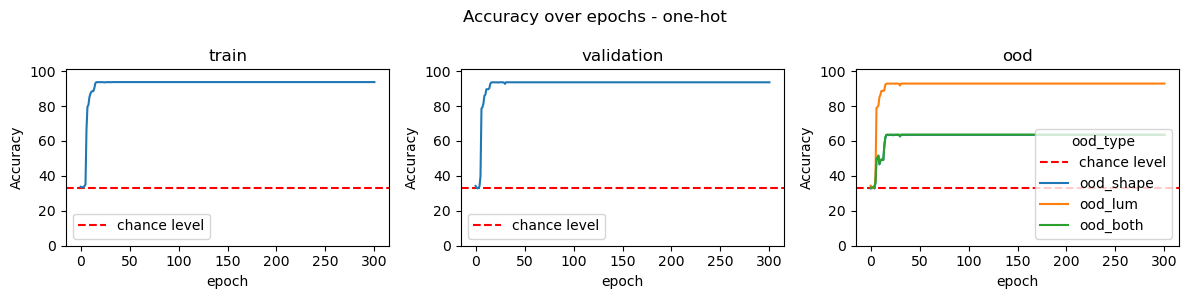

In [6]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    res["dataset_type"] = pd.Categorical(
        [x if x in ["train","validation"] else "ood" for x in res['dataset']],
        categories = ["train","validation","ood"],
        ordered=True
    )

    for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):
        chance_level = 100 * (1/3)
        ax_acc[j].axhline(chance_level, color='red', linestyle='--', label='chance level')
        if ds == 'ood':
            # further split by test shapes and lums
            dsdf = dsdf.copy()            
            dsdf['ood_type'] = dsdf["dataset"]
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', hue='ood_type', ax=ax_acc[j])
            

        else:
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', ax=ax_acc[j])
        
        ax_acc[j].set_ylim(0, 101)        
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Accuracy')

    fig_acc.suptitle(f'Accuracy over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_3318/2661553813.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):


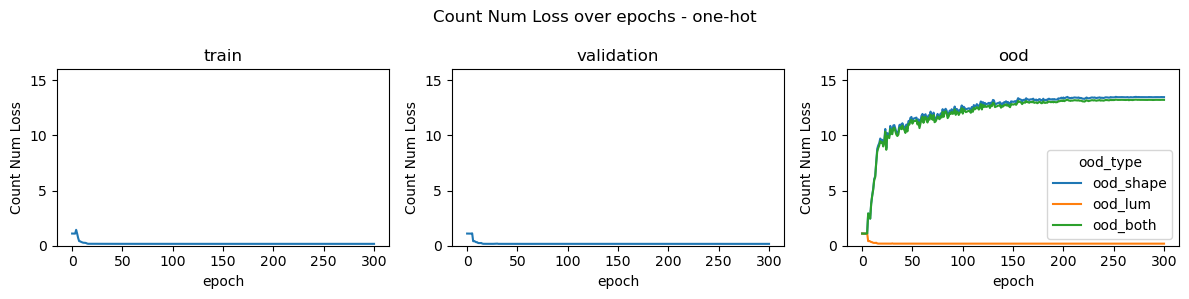

In [7]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    res["dataset_type"] = pd.Categorical(
        [x if x in ["train","validation"] else "ood" for x in res['dataset']],
        categories = ["train","validation","ood"],
        ordered=True
    )
    for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['ood_type'] = dsdf["dataset"]
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', ax=ax_acc[j])

        ax_acc[j].set_ylim(0, 16)
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Num Loss')

    fig_acc.suptitle(f'Count Num Loss over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_43117/2157091787.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):


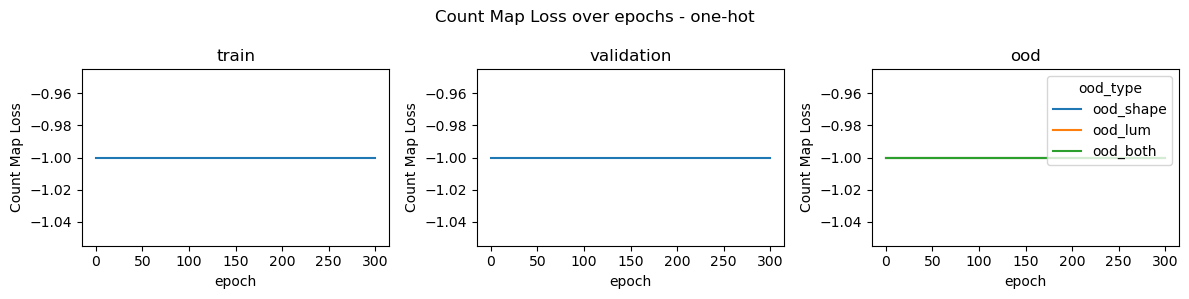

In [22]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    res["dataset_type"] = pd.Categorical(
        [x if x in ["train","validation"] else "ood" for x in res['dataset']],
        categories = ["train","validation","ood"],
        ordered=True
    )
    for j, (ds, dsdf) in enumerate(res.groupby('dataset_type')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['ood_type'] = dsdf["dataset"]
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', ax=ax_acc[j])

        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Map Loss')

    fig_acc.suptitle(f'Count Map Loss over epochs - {rsname}')
    plt.tight_layout()

## confusion matrix

In [9]:
conf_dir = res_dirs
conf_files = glob.glob(os.path.join(conf_dir, "confusion_*.npy"))
conf_files = [f for f in conf_files if "at_" not in f]
conf_files

['results_min7_max7_pairs_v1/logpolar/confusion_rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.npy']

In [11]:
conf_lists = {}
shortconfnames = dict(zip(conf_files,
                           ["one-hot"]))
        
for conf_file,sn in shortconfnames.items():
    conf_lists[sn] = np.load(conf_file)

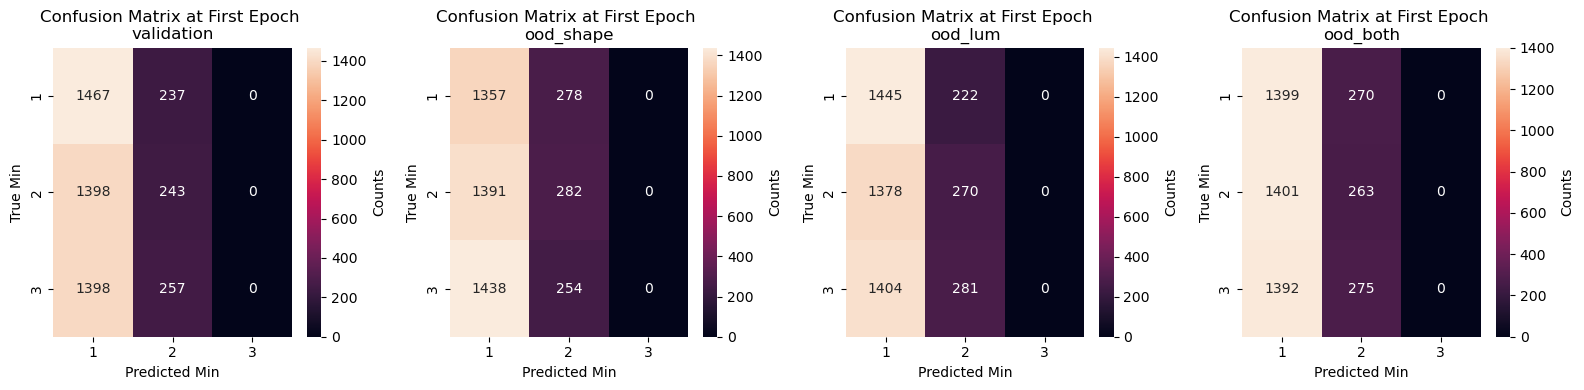

In [12]:
conf = conf_lists["one-hot"]
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[0])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at First Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

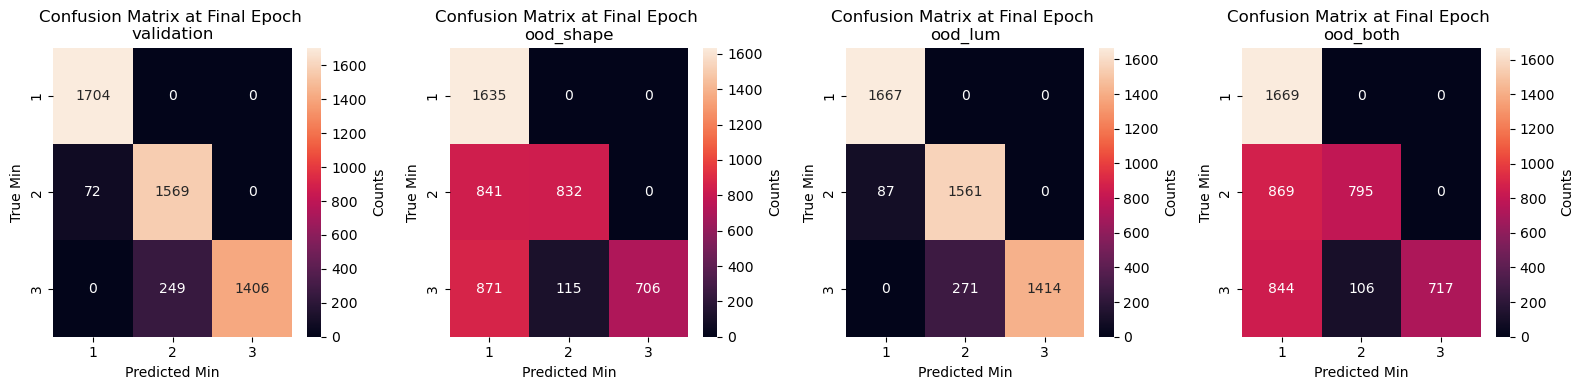

In [13]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

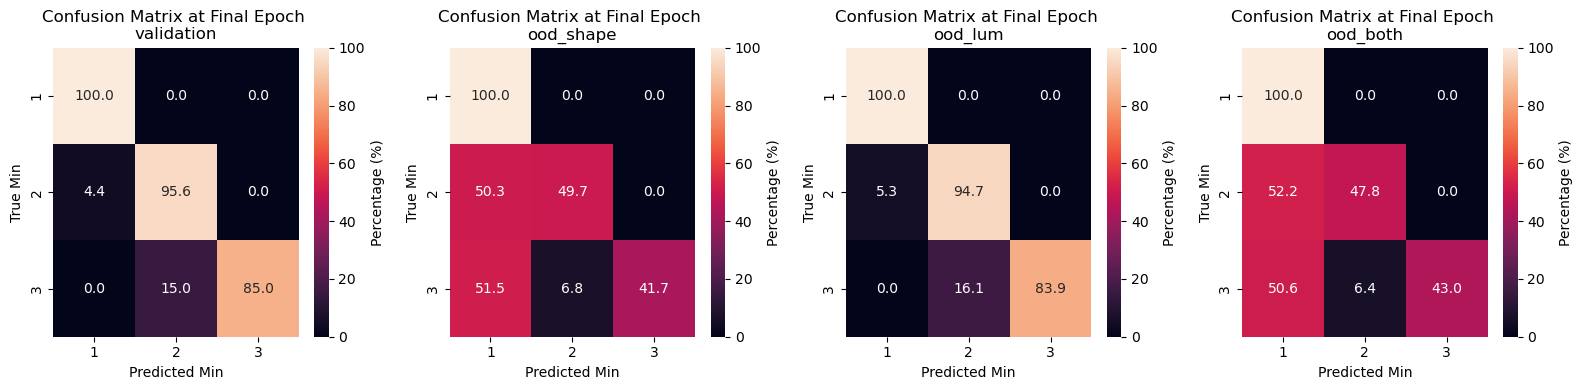

In [14]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax, 
                cbar_kws={'label': 'Percentage (%)'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

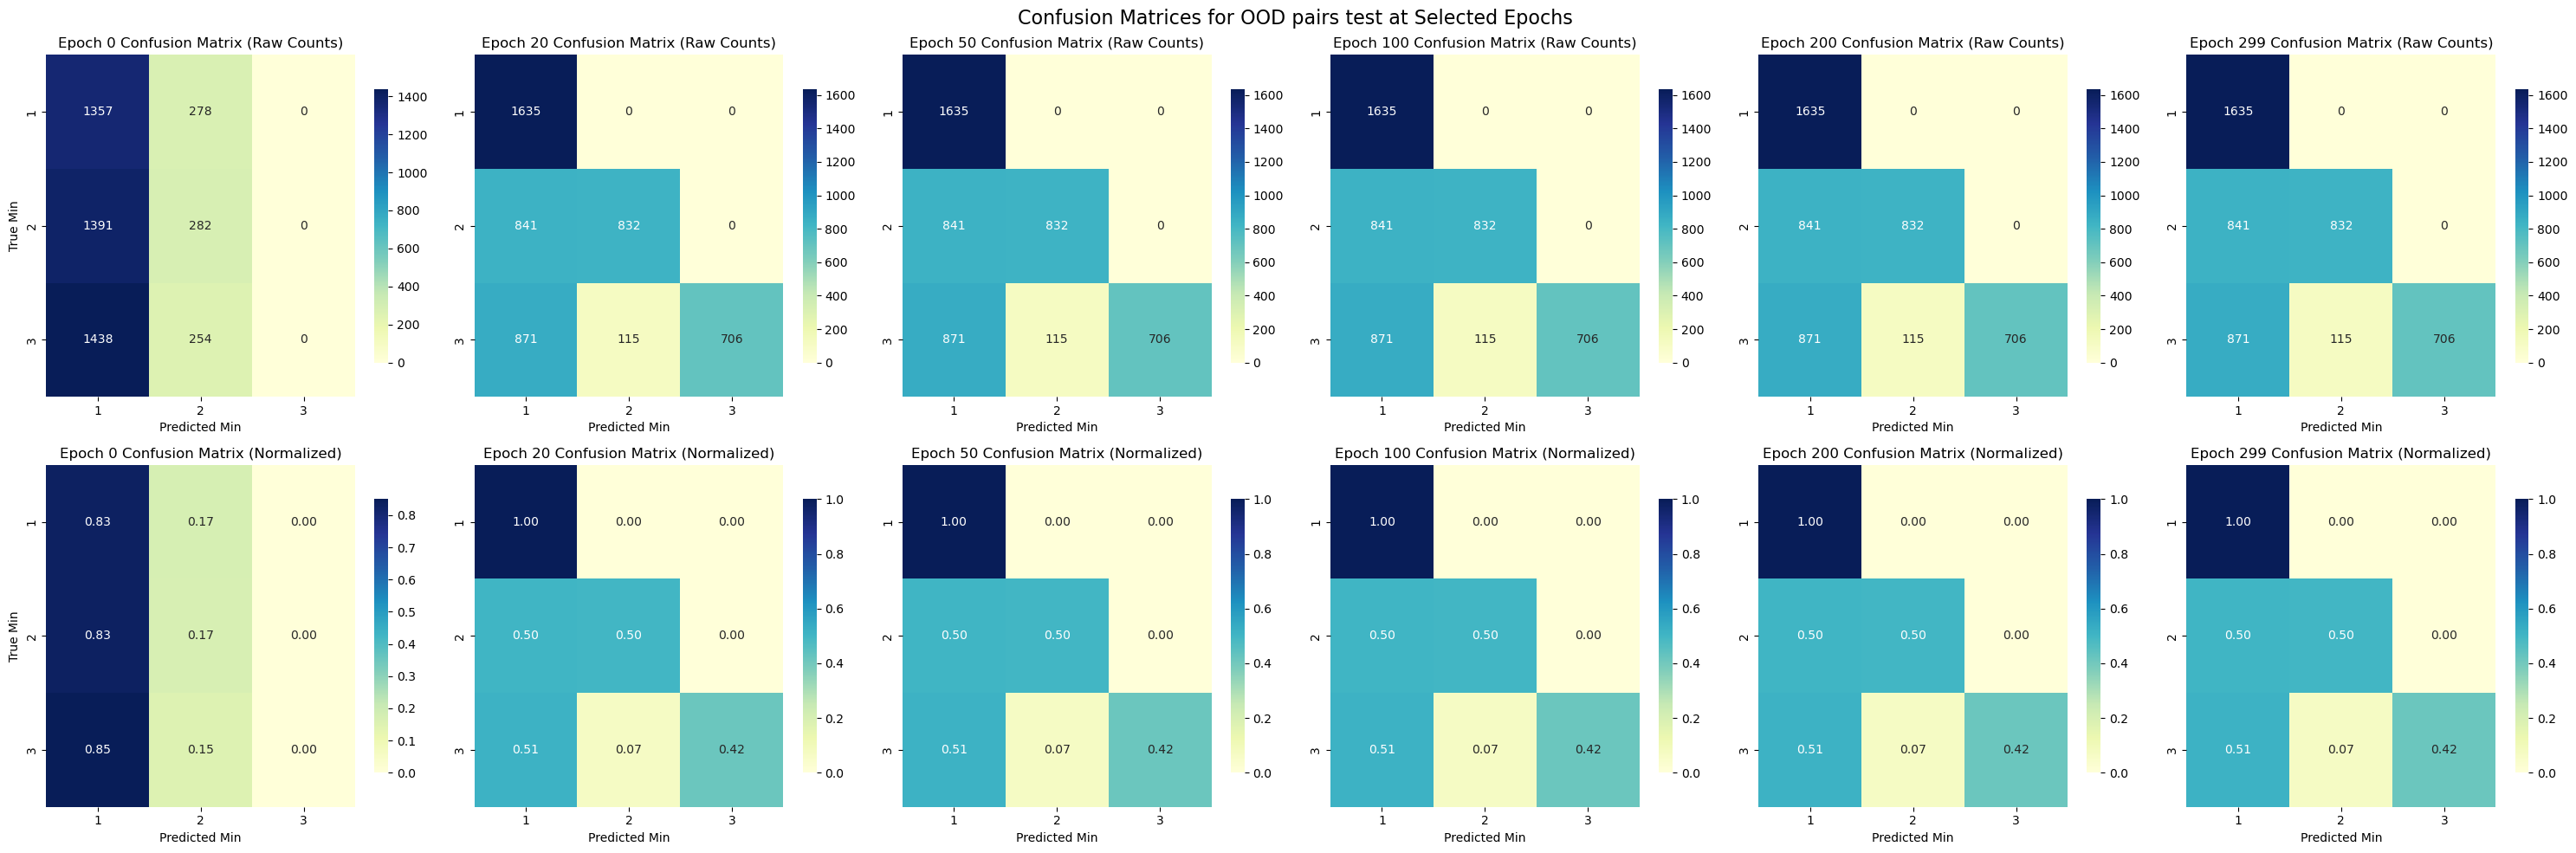

In [15]:
conf = conf_lists["one-hot"]
checkpoints = np.array([0, 20, 50,100,200, 299])  # zero-based indices
n_checkpoints = len(checkpoints)

conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
plt_conf = "ood_shape"
plt_loc = conf_names.index(plt_conf)
# display two rows, one the raw confusion matrix, one normalized, with heatmaps
fig, axes = plt.subplots(2, n_checkpoints, figsize=(5*n_checkpoints, 10))
for i, cp in enumerate(checkpoints):
    ax = axes[0, i] if n_checkpoints > 1 else axes[0]
    c = conf[cp][plt_loc]
    sns.heatmap(c, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
                cbar_kws={"shrink": 0.8},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Epoch {cp} Confusion Matrix (Raw Counts)')

    axn = axes[1, i] if n_checkpoints > 1 else axes[1]
    sns.heatmap(c / c.sum(axis=1, keepdims=True), annot=True, fmt='.2f', cmap='YlGnBu', ax=axn,
                cbar_kws={"shrink": 0.8},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    axn.set_title(f'Epoch {cp} Confusion Matrix (Normalized)')

    if i == 0:
        ax.set_ylabel('True Min')
        axn.set_ylabel('True Min')
    ax.set_xlabel('Predicted Min')
    axn.set_xlabel('Predicted Min')

fig.suptitle(f'Confusion Matrices for {plt_conf if plt_conf!="ood_shape" else "OOD pairs"} test at Selected Epochs', fontsize=16)
plt.tight_layout()

## Activations

In [16]:
actv_dir = "activations_min7_max7_pairs_v1"
actv_filepat = {
    "validation": "*trained_test-validation.npz",
    "OODlum":     "*trained_test-new-luminances.npz",
    "OODpairs":   "*trained_test-new-shapes.npz",
    "OODboth":    "*trained_test-new_both.npz"
}
actv_files = {
    k: glob.glob(os.path.join(actv_dir, v))
    for k,v in actv_filepat.items()
}
assert all([len(v)==1 for v in actv_files.values()]), "Expected exactly one activation file per dataset type"
print(actv_files)


{'validation': ['activations_min7_max7_pairs_v1/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_trained_test-validation.npz'], 'OODlum': ['activations_min7_max7_pairs_v1/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_trained_test-new-luminances.npz'], 'OODpairs': ['activations_min7_max7_pairs_v1/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_trained_test-new-shapes.npz'], 'OODboth': ['activations_min7_max7_pairs_v1/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_trained

In [43]:
ds_dir = "minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1"
file_pat = {
    "train":      "*_pair-train_*_lum[[]0.1, 0.4, 0.7[]]*_100000.pkl",
    "validation": "*_pair-train_*_lum[[]0.1, 0.4, 0.7[]]*_5000.pkl",
    "OODlum":     "*_pair-train_*_lum[[]0.3, 0.6, 0.9[]]*_5000.pkl",
    "OODpairs":   "*_pair-test_*_lum[[]0.1, 0.4, 0.7[]]*_5000.pkl",
    "OODboth":    "*_pair-test_*_lum[[]0.3, 0.6, 0.9[]]*_5000.pkl"
}
ds_paths = {}
for k, v in file_pat.items():
    print(f"Looking for {k} dataset files...")
    files = glob.glob(os.path.join(ds_dir, v))
    assert len(files) == 1, f"Expected exactly one file for {k}, found {len(files)}"
    print(f"{k} dataset file: {files[0]}")
    ds_paths[k] = files[0]



Looking for train dataset files...
train dataset file: minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1/num7-7_nl-0.74_BCDEFGHJdistinct-0.3_pair-train_grid6_policy-cheat+jitter_lum[0.1, 0.4, 0.7]_logpolar_12_100000.pkl
Looking for validation dataset files...
validation dataset file: minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1/num7-7_nl-0.74_BCDEFGHJdistinct-0.3_pair-train_grid6_policy-cheat+jitter_lum[0.1, 0.4, 0.7]_logpolar_12_5000.pkl
Looking for OODlum dataset files...
OODlum dataset file: minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1/num7-7_nl-0.74_BCDEFGHJdistinct-0.3_pair-train_grid6_policy-cheat+jitter_lum[0.3, 0.6, 0.9]_logpolar_12_5000.pkl
Looking for OODpairs dataset files...
OODpairs dataset file: minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1/num7-7_nl-0.74_BCDEFGHJdistinct-0.3_pair-test_grid6_policy-cheat+jitter_lum[0.1, 0.4, 0.7]_logpolar_12_5000.pkl
Looking for OODboth dataset files...
OODboth dataset file: minmaxdatasets/image_sets_min_max_pair

In [56]:
checkds = "OODpairs"
actv_file = ds_paths[checkds]
print("Activations", checkds, actv_file)
activation_data = np.load(actv_file,allow_pickle=True)
for k,v in activation_data.items():
    print(k, v.shape)

ds = load(ds_paths[checkds])
ds.keys()

Activations OODpairs minmaxdatasets/image_sets_min_max_pairs_min7_max7_v1/num7-7_nl-0.74_BCDEFGHJdistinct-0.3_pair-test_grid6_policy-cheat+jitter_lum[0.1, 0.4, 0.7]_logpolar_12_5000.pkl
glimpse_coords_1x1 (5000,)
symbolic_shape (5000,)
numerosity_target (5000,)
numerosity_dist (5000,)
numerosity_min (5000,)
numerosity_max (5000,)
num_unique (5000,)
glimpse_shape_onehot (5000,)
locations (5000,)
locations_class_min (5000,)
locations_class_max (5000,)
locations_class_index (5000,)
locations_count (5000,)
locations_distract (5000,)
object_coords (5000,)
shape_map (5000,)
shape_hist (5000,)
target_coords_1x1 (5000,)
distract_coords_1x1 (5000,)
target_coords_scaled (5000,)
target_coords_image (5000,)
distract_coords_scaled (5000,)
transform (5000,)


Index(['glimpse_coords_1x1', 'symbolic_shape', 'numerosity_target',
       'numerosity_dist', 'numerosity_min', 'numerosity_max', 'num_unique',
       'glimpse_shape_onehot', 'locations', 'locations_class_min',
       'locations_class_max', 'locations_class_index', 'locations_count',
       'locations_distract', 'object_coords', 'shape_map', 'shape_hist',
       'target_coords_1x1', 'distract_coords_1x1', 'target_coords_scaled',
       'target_coords_image', 'distract_coords_scaled', 'transform'],
      dtype='object')

In [50]:
activation_data["numerosity_min"]

0       1
1       2
2       3
3       3
4       3
       ..
4995    3
4996    3
4997    3
4998    1
4999    2
Name: numerosity_min, Length: 5000, dtype: int64

In [51]:
pairs = []
correct_labels = []
correct_label_inpairs = []
num_min = []
for x in ds["shape_map"]:
    labels, counts = np.unique_counts(list(x.values()))
    min_label = labels[np.argmin(counts)]
    pairs.append(f"{labels[0]}_{labels[1]}")
    correct_labels.append(min_label)
    if counts[0] < counts[1]:
        correct_label_inpairs.append("l1")
    else:
        correct_label_inpairs.append("l2")
    num_min.append(counts.min())

dataset_df = pd.DataFrame({"pair": pairs, "min_count": num_min,
                    "min_label": correct_labels, "correct_label_inpairs": correct_label_inpairs})

In [53]:
np.array_equal(dataset_df["min_count"].values, activation_data["numerosity_min"])

True

In [54]:
# plot activity across time for selected neurons and for different trialtypes
df = dataset_df.copy()
df["prediction"] = np.argmax(activation_data["predicted_num"], axis=1) + 1
df["correct"] = df["prediction"] == df["min_count"]
assert np.array_equal(df["correct"].values,activation_data["correct"])
X = activation_data["act_hidden"].copy().T
for trial_type_var in ['pair', 'min_count', 'min_label']:
    unique_types = dataset_df[trial_type_var].unique()
    n_types = len(unique_types)
    fig, axes = plt.subplots(1, n_types, figsize=(5*n_types,4))
    for i, ut in enumerate(unique_types):
        ax = axes[i] if n_types > 1 else axes
        #neuron_selector = neuron_factors[:,sort_by] > 0
        trial_selector  = dataset_df[trial_type_var] == ut
        # plot average activity for selected neurons in selected trials
        mean_temporal = X[:,:,trial_selector.values].mean(axis=2)
        mean_temporal_neurons = mean_temporal.mean(axis=0)
        time_points = np.arange(12) + 1 # assuming 12 glimpses
        ax.plot(time_points, mean_temporal_neurons)
        ax.set_title(f'Activity Level for Neurons in {trial_type_var}={ut}')
        ax.set_xlabel('# Glimpse')
        ax.set_ylabel('Activity Level')

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'predicted_num'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/

In [92]:
import tensortools as tt
ensemble = tt.Ensemble(fit_method="ncp_hals")
from sklearn.metrics import r2_score
# do in cv
X = activation_data["act_hidden"].copy().T
ensemble.fit(X, ranks=range(1,20), replicates=1)


Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 18.2s


Rank-2 models:  min obj, 0.81;  max obj, 0.81;  time to fit, 19.7s


Rank-3 models:  min obj, 0.77;  max obj, 0.77;  time to fit, 64.6s


Rank-4 models:  min obj, 0.77;  max obj, 0.77;  time to fit, 43.6s


Rank-5 models:  min obj, 0.76;  max obj, 0.76;  time to fit, 103.5s


...

Rank-15 models:  min obj, 0.65;  max obj, 0.65;  time to fit, 73.2s


Rank-16 models:  min obj, 0.65;  max obj, 0.65;  time to fit, 79.1s


Rank-17 models:  min obj, 0.64;  max obj, 0.64;  time to fit, 167.8s


Rank-18 models:  min obj, 0.63;  max obj, 0.63;  time to fit, 132.1s


Rank-19 models:  min obj, 0.63;  max obj, 0.63;  time to fit, 109.5s


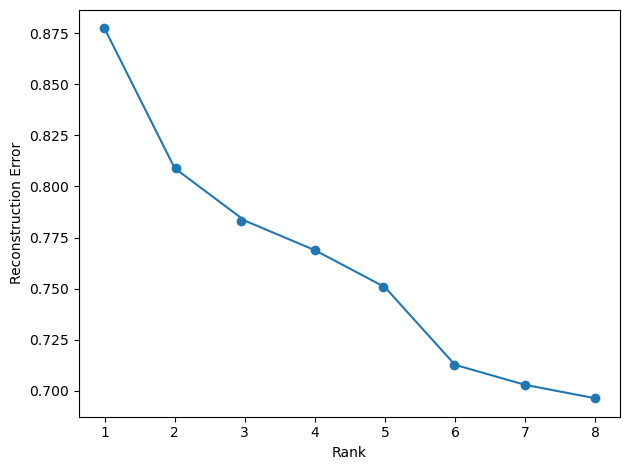

In [80]:
fig,ax = plt.subplots(1,1)
tt.plot_objective(ensemble, ax=ax)
ax.set_xlabel('Rank')
ax.set_ylabel('Reconstruction Error')
fig.tight_layout()

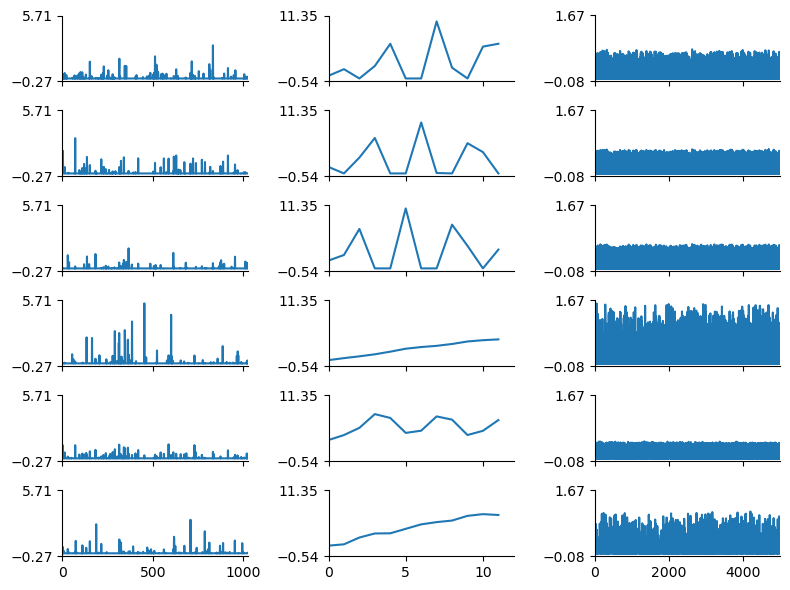

In [81]:
num_components = 6
replicate = 0
tt.plot_factors(ensemble.factors(num_components)[replicate])
plt.show()

In [87]:
dataset_df

,pair,min_count,correct_label,correct_label_inpairs
0,4_6,3,4,l1
1,4_6,3,6,l2
2,3_7,1,3,l1
3,3_7,2,3,l1
4,2_5,1,2,l1
...,...,...,...,...
4995,2_4,3,4,l2
4996,3_9,2,9,l2
4997,3_6,1,3,l1
4998,1_7,3,1,l1


0.0 5.441659174377509
0.0 5.441659174377509
0.0 5.441659174377509
0.0 5.441659174377509
0.0 5.441659174377509
0.0 5.441659174377509


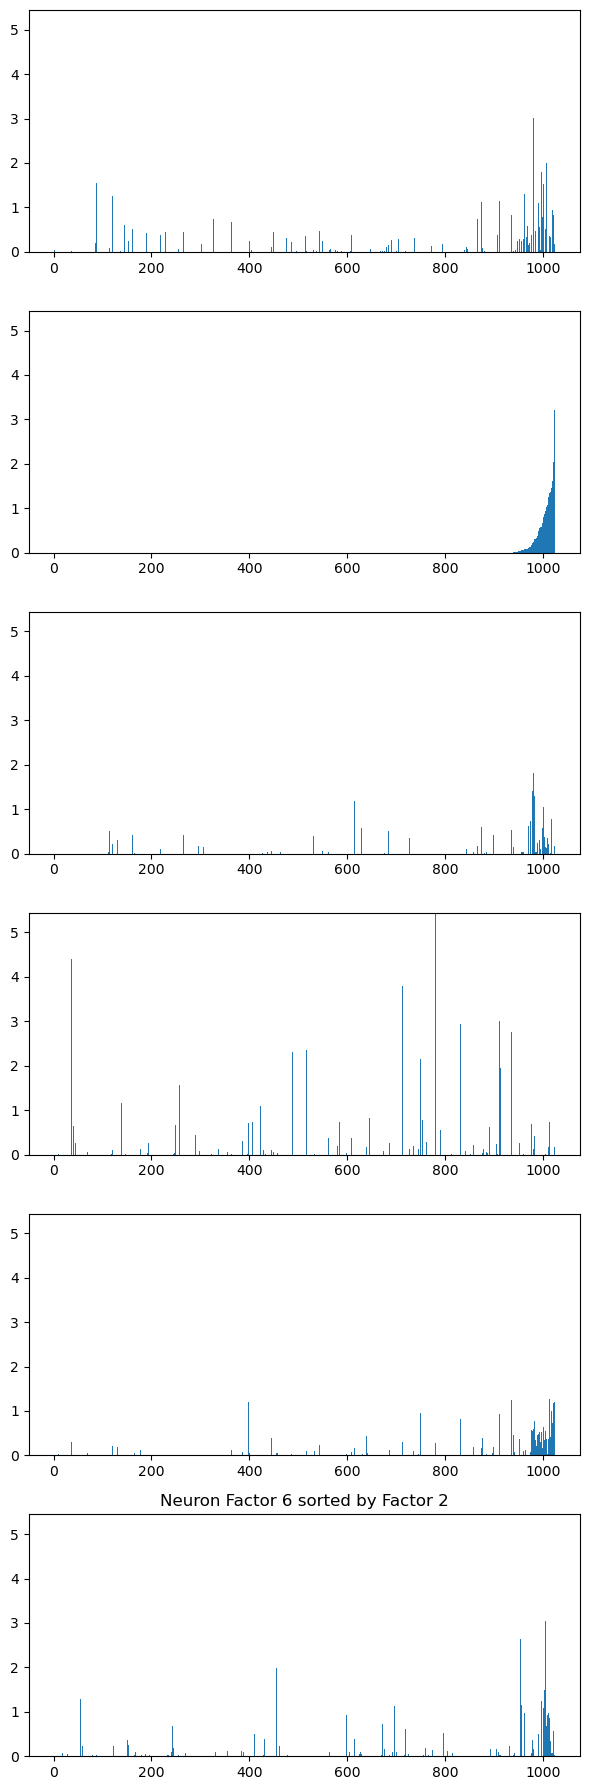

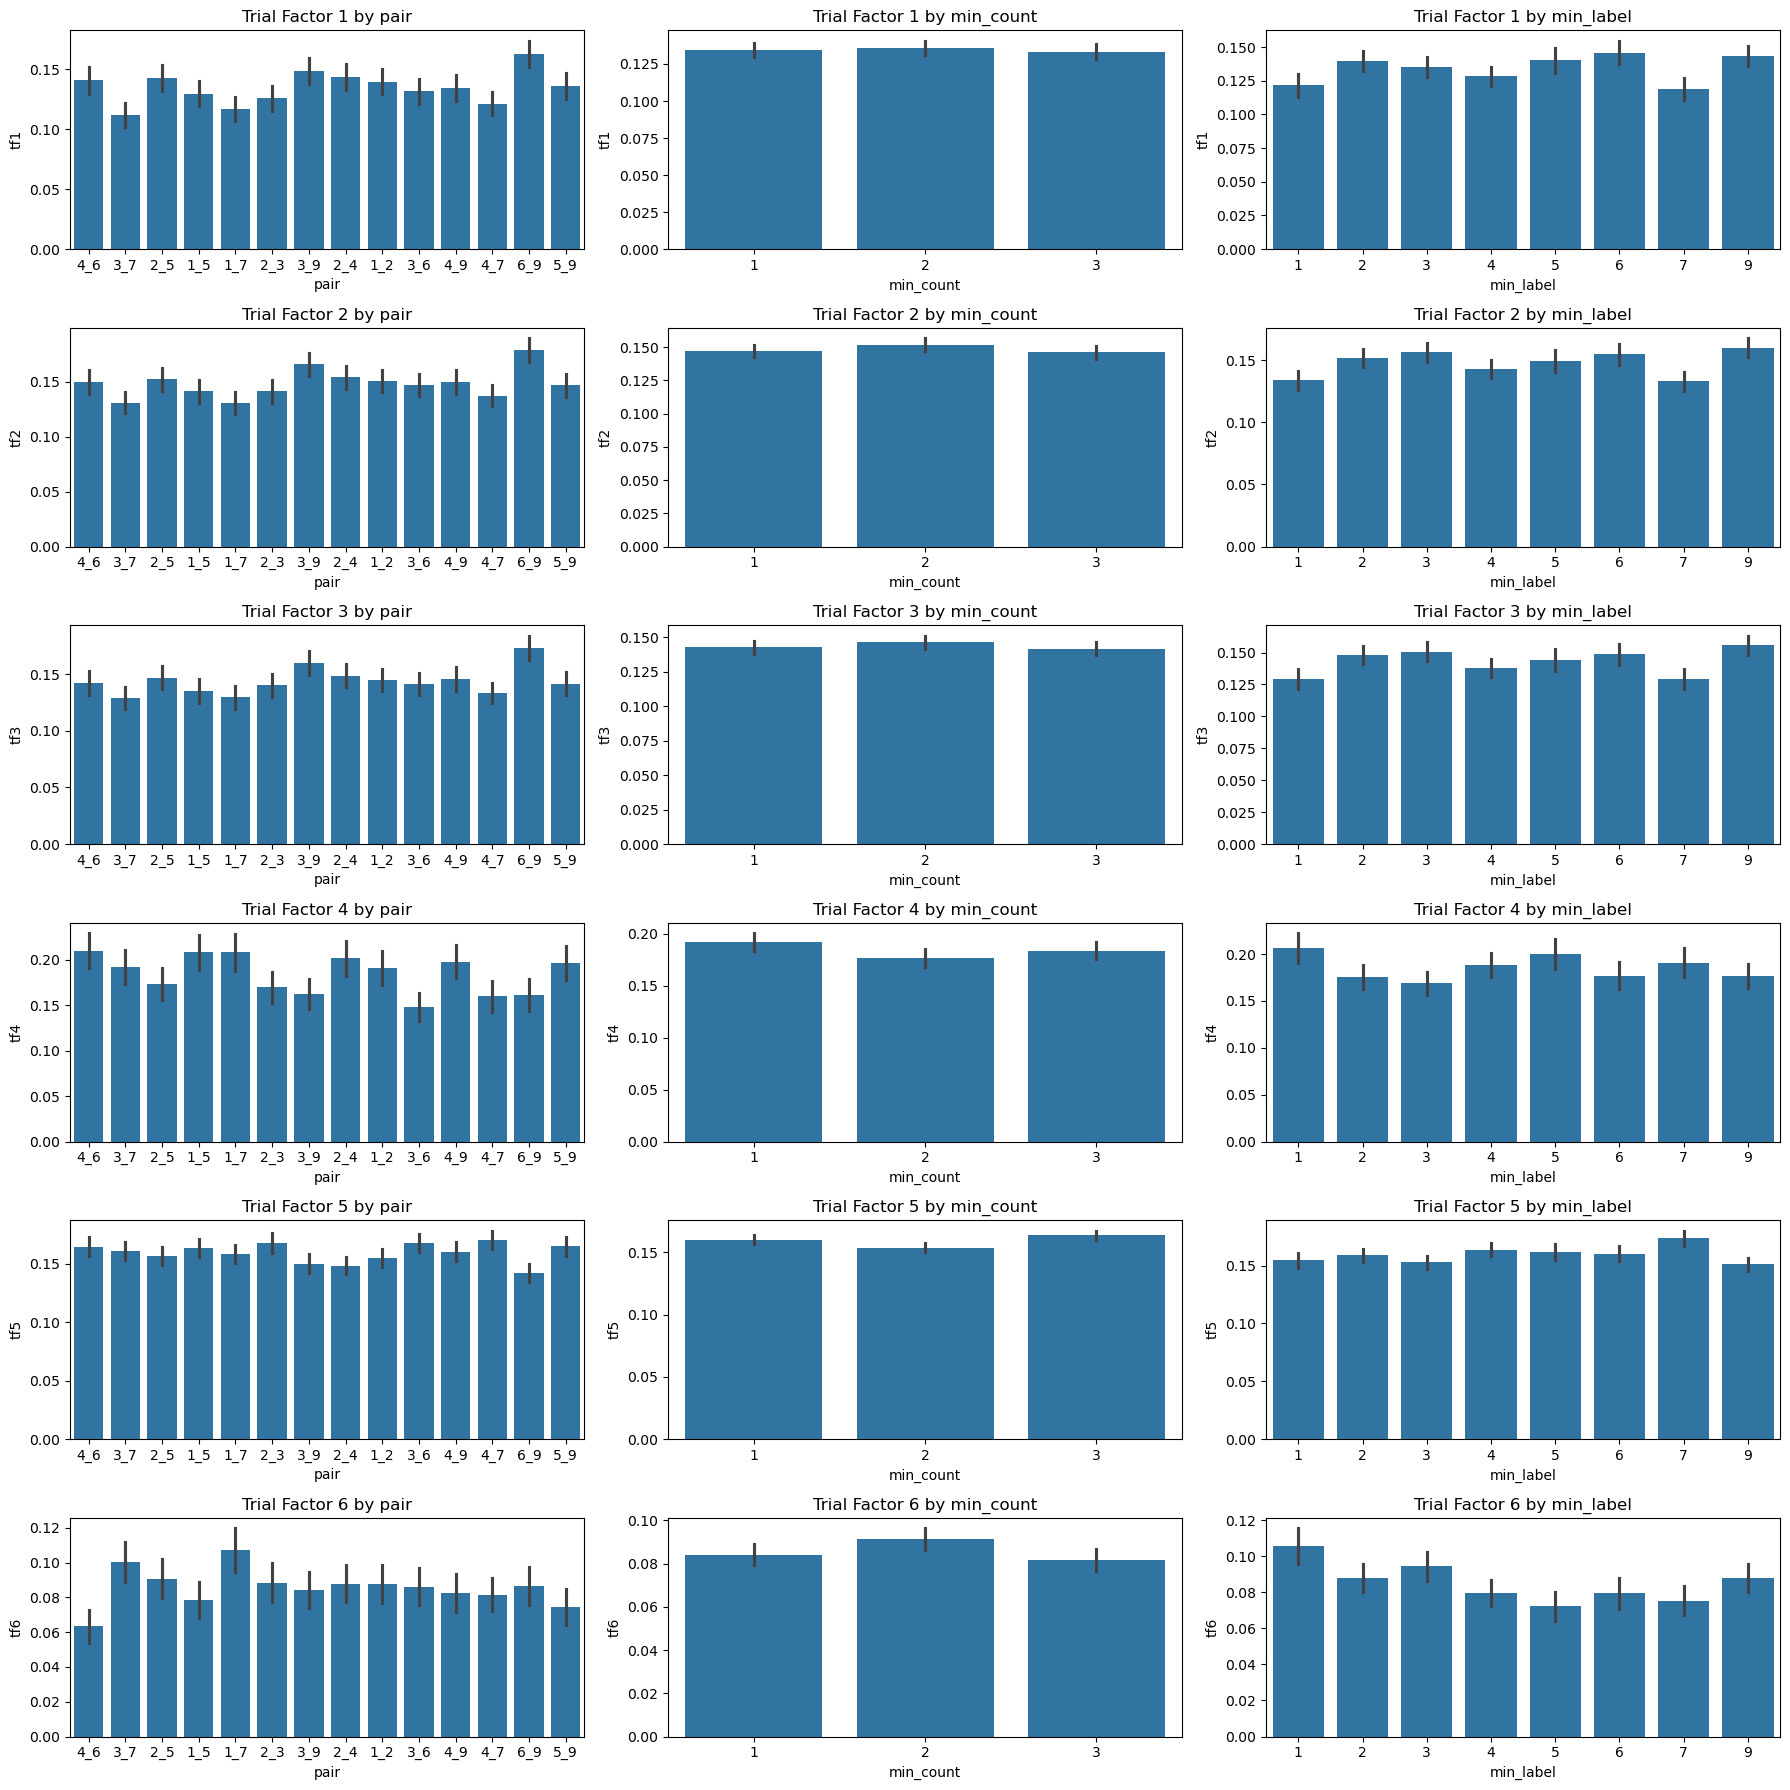

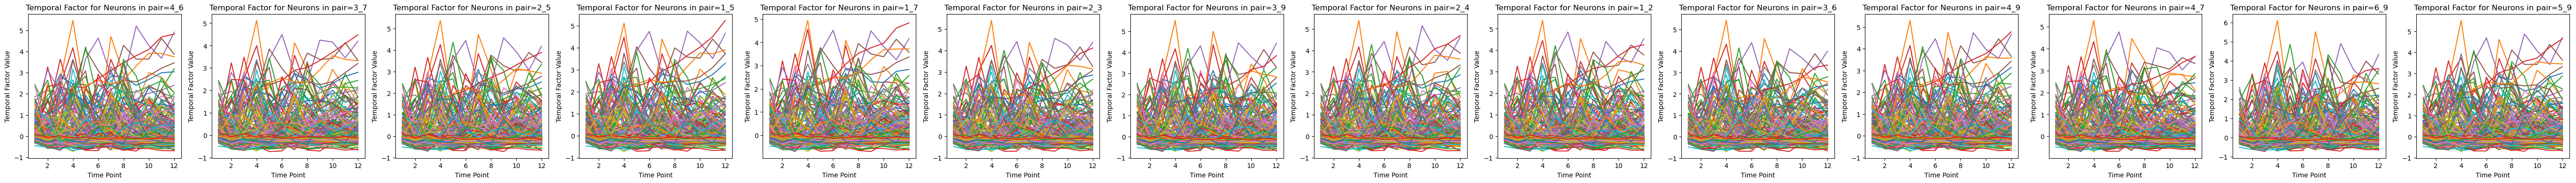

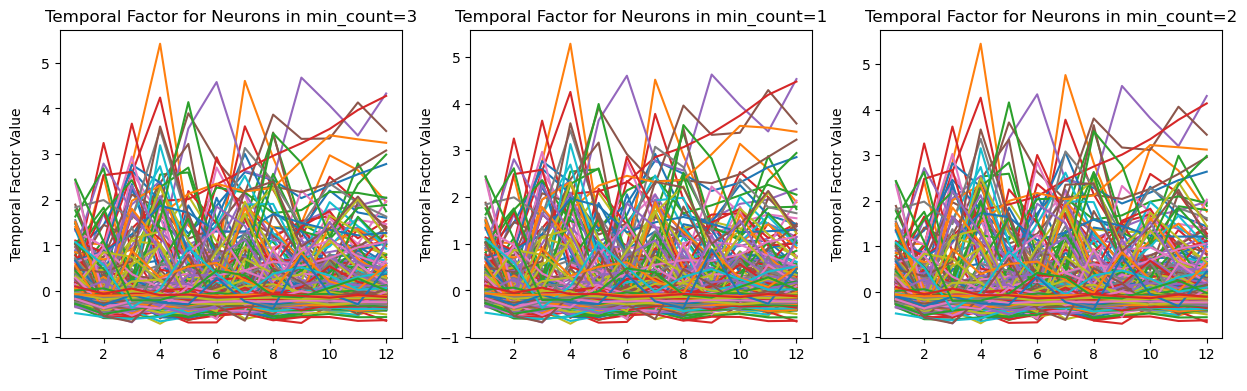

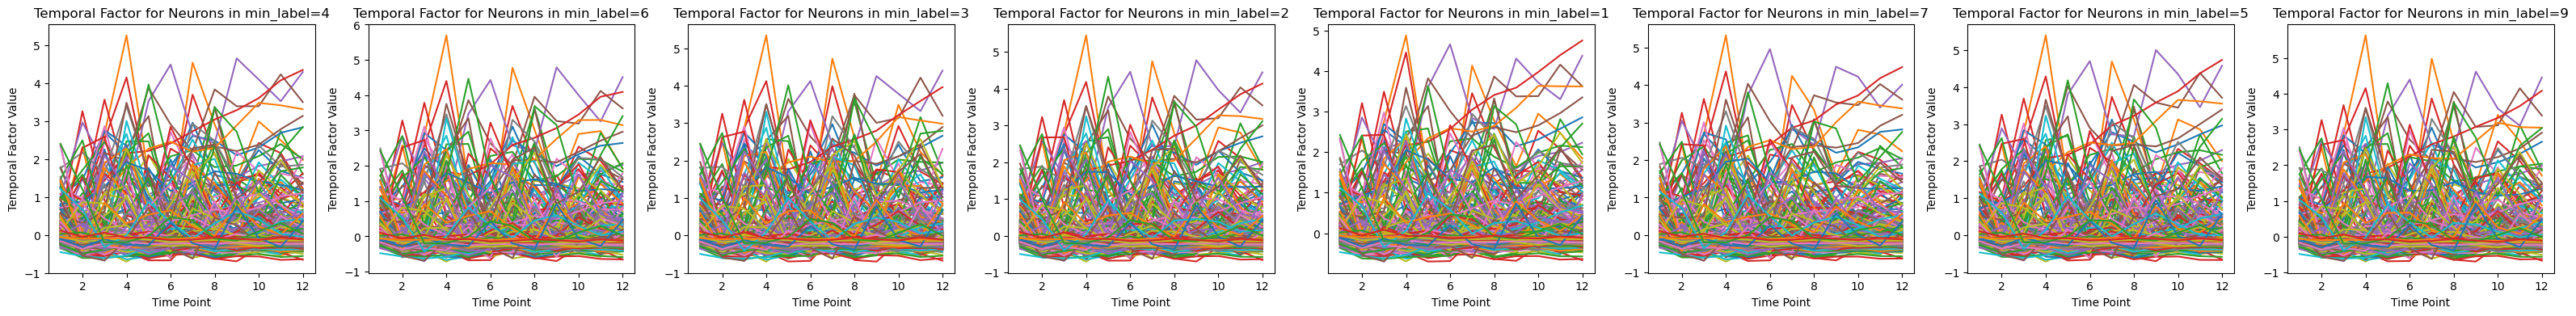

In [ ]:
# sort neuron by index
import numpy as np
num_components = 6
replicate = 0
sort_by = 1
plotU = ensemble.factors(num_components)[replicate]
neuron_factors = plotU[0] # first factor corresponds to neurons
sorted_indices = np.argsort(neuron_factors[:,sort_by])

temporal_factors = plotU[1] # second factor corresponds to time
trial_factors = plotU[2]    # third factor corresponds to trials



fig, axes = plt.subplots(plotU.rank, 1, figsize=(6*1, 3*plotU.rank))
for r in range(plotU.rank):
    #for i,f in enumerate(plotU):
    print(np.min(neuron_factors), np.max(neuron_factors))
    x = np.arange(1, neuron_factors.shape[0]+1)
    axes[r].bar(x, neuron_factors[:, r][sorted_indices],width=2.0)
    axes[r].set_ylim(np.min(neuron_factors), np.max(neuron_factors))
    if r == plotU.rank - 1:
        axes[r].set_title(f'Neuron Factor {r+1} sorted by Factor {sort_by+1}')
    else:
        axes[r].set_title(f'')
plt.tight_layout()



df = dataset_df.copy().rename(columns={"correct_label": "min_label"})

for idx in range(trial_factors.shape[1]):
    df[f"tf{idx+1}"] = trial_factors[:, idx]

xvars = ['pair', 'min_count', 'min_label']
fig, axes = plt.subplots(plotU.rank, len(xvars), figsize=(6*len(xvars), 3*plotU.rank))
for r in range(plotU.rank):
    for c, xvar in enumerate(xvars):
        sns.barplot(data=df, x=xvar, y=f'tf{r+1}', ax=axes[r, c],errorbar='se')
        axes[r, c].set_title(f'Trial Factor {r+1} by {xvar}')
plt.tight_layout()


# plot activity across time for selected neurons and for different trialtypes
for trial_type_var in xvars:
    unique_types = df[trial_type_var].unique()
    n_types = len(unique_types)
    fig, axes = plt.subplots(1, n_types, figsize=(5*n_types,4))
    for i, ut in enumerate(unique_types):
        ax = axes[i] if n_types > 1 else axes
        #neuron_selector = neuron_factors[:,sort_by] > 0
        trial_selector  = df[trial_type_var] == ut
        # plot average activity for selected neurons in selected trials
        mean_temporal = X[:,:,trial_selector.values].mean(axis=2)
        #std_temporal = X[:,:,trial_selector].std(axis=2)
        time_points = np.arange(1, temporal_factors.shape[0]+1)
        for mt in mean_temporal:
            ax.plot(time_points, mt)
        ax.set_title(f'Activity Level for Neurons in {trial_type_var}={ut}')
        ax.set_xlabel('Time Point')
        ax.set_ylabel('Activity Level')
# fig, ax = plt.subplots(1,1)
# neuron_selector = neuron_factors[:,sort_by] > 0
# trial_selector  = activation_data["correct"] == 1
# # plot average activity for selected neurons in selected trials
# mean_temporal = X[neuron_selector][:,:,trial_selector].mean(axis=2)
# #std_temporal = X[neuron_selector][:,:,trial_selector].std(axis=2)
# time_points = np.arange(1, temporal_factors.shape[0]+1)
# for mt in mean_temporal:
#     ax.plot(time_points, mt)
# ax.set_title('Temporal Factor for Selected Neurons in Correct Trials')
# ax.set_xlabel('Time Point')
# ax.set_ylabel('Temporal Factor Value')
# ax.legend()



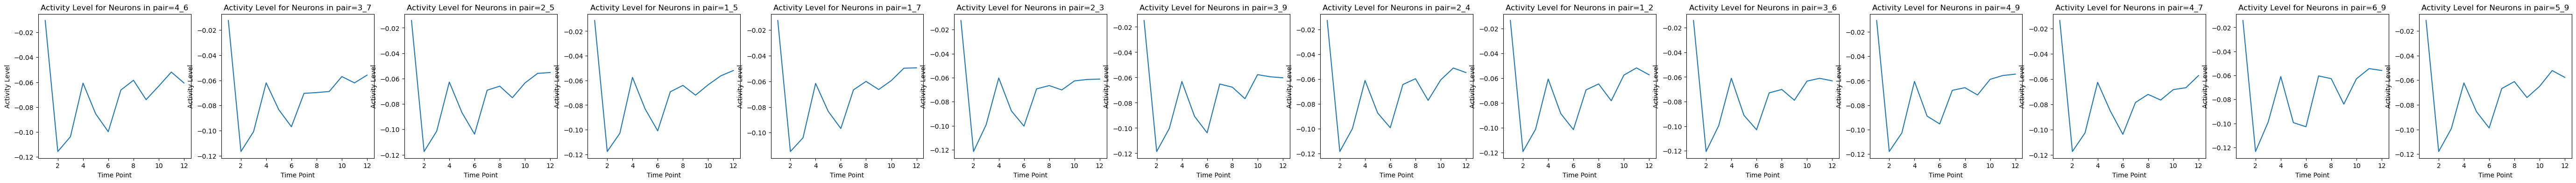

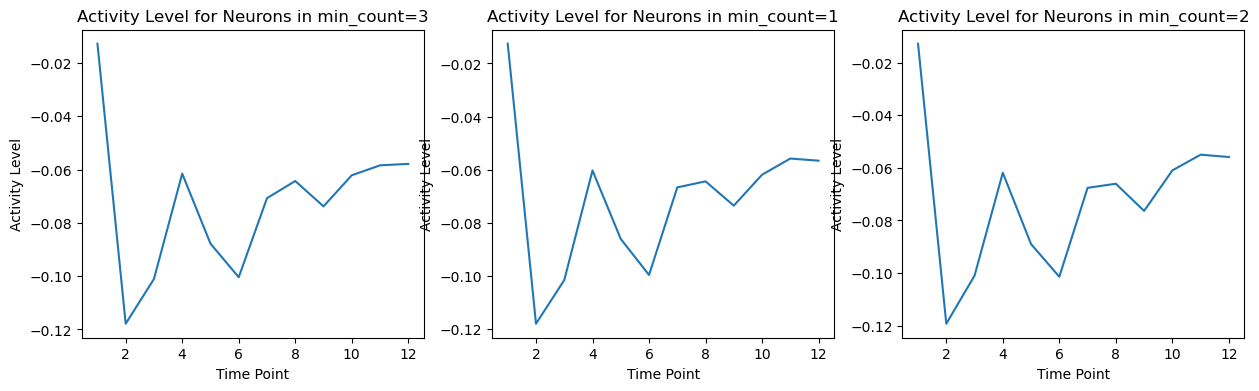

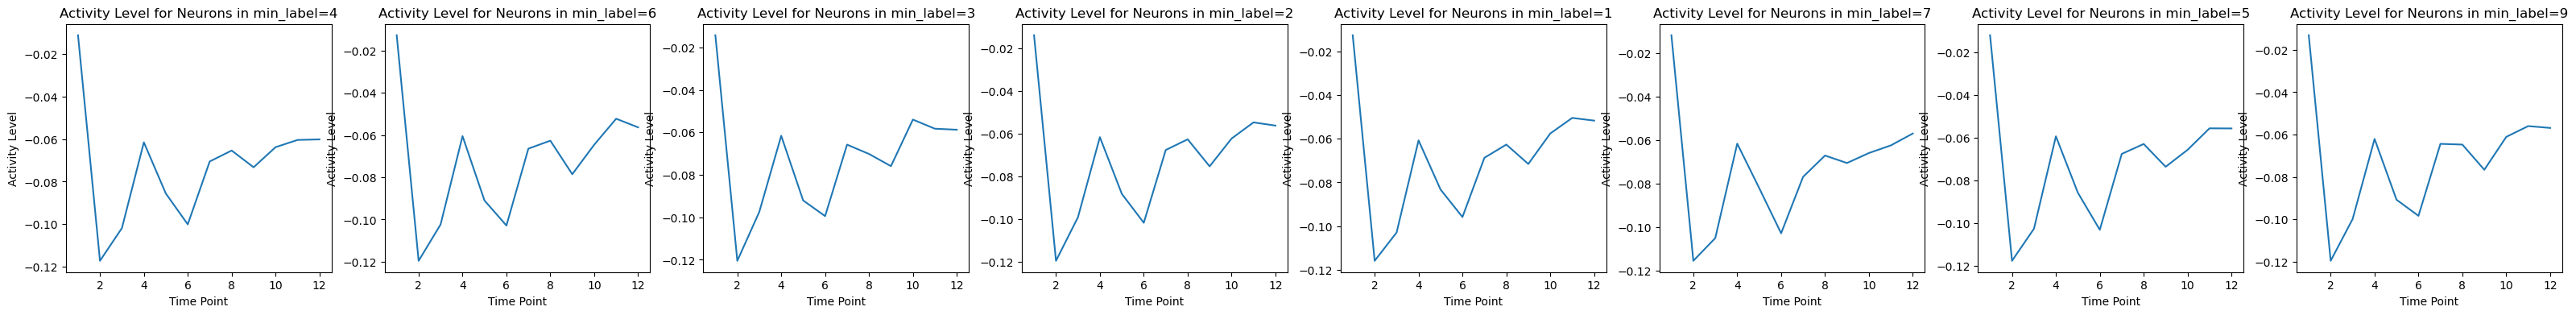

In [91]:
# plot activity across time for selected neurons and for different trialtypes
for trial_type_var in xvars:
    unique_types = df[trial_type_var].unique()
    n_types = len(unique_types)
    fig, axes = plt.subplots(1, n_types, figsize=(5*n_types,4))
    for i, ut in enumerate(unique_types):
        ax = axes[i] if n_types > 1 else axes
        #neuron_selector = neuron_factors[:,sort_by] > 0
        trial_selector  = df[trial_type_var] == ut
        # plot average activity for selected neurons in selected trials
        mean_temporal = X[:,:,trial_selector.values].mean(axis=2)
        mean_temporal_across_neurons = mean_temporal.mean(axis=0)
        #std_temporal = X[:,:,trial_selector].std(axis=2)
        time_points = np.arange(1, temporal_factors.shape[0]+1)
        ax.plot(time_points, mean_temporal_across_neurons)
        ax.set_title(f'Activity Level for Neurons in {trial_type_var}={ut}')
        ax.set_xlabel('Time Point')
        ax.set_ylabel('Activity Level')

In [ ]:
# get the content of each glimpses
n_glimpses = 12
glimpse_contents = []
for trial_gs_onehot in ds["glimpse_shape_onehot"]:
    trial_gs = np.concatenate([np.where(g==1)[0] for g in trial_gs_onehot]) 
    assert len(trial_gs) == n_glimpses
    glimpse_contents.append(trial_gs)



# Saved Trained model

In [30]:
import torch
model_dir = "models_min7_max7_pairs_v1/logpolar"
#model_file = glob.glob(os.path.join(model_dir, "pretrained_ventral*.pt"))[0]
model_file = glob.glob(os.path.join(model_dir, "rnn_classifier2stream*.pt"))[0]
print(model_file)
ventral_model_file = glob.glob(os.path.join(model_dir,"ventral","*.pt"))[0]
ventral_model_file
saved_model = torch.load(model_file)


models_min7_max7_pairs_v1/logpolar/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_ep-300.pt


/tmp/ipykernel_43117/1705822320.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model = torch.load(model_file)


In [31]:
saved_model.rnn

RNN(
  (act_fun): LeakyReLU(negative_slope=0.1)
  (i2h): Linear(in_features=2048, out_features=1024, bias=True)
  (h2o): Linear(in_features=1024, out_features=1024, bias=True)
)

In [32]:
# ------------------------
# After training: inspect learned weights (quick print)
# ------------------------
model_weights = {}
print("\nModel parameter summary (name, shape, L2 norm):")
for name, p in saved_model.named_parameters():
    print(f"{name} {tuple(p.shape)}  L2={p.detach().cpu().norm().item():.4f}")
    model_weights[name] = p.detach().cpu().numpy()




Model parameter summary (name, shape, L2 norm):
pix_embedding.weight (512, 25)  L2=13.7161
pix_embedding.bias (512,)  L2=1.8505
xy_embedding.weight (512, 2)  L2=11.2832
xy_embedding.bias (512,)  L2=6.2268
joint_embedding.weight (1024, 1024)  L2=29.1947
joint_embedding.bias (1024,)  L2=0.6859
rnn.i2h.weight (1024, 2048)  L2=64.2053
rnn.i2h.bias (1024,)  L2=1.2392
rnn.h2o.weight (1024, 1024)  L2=53.2127
rnn.h2o.bias (1024,)  L2=0.8910
map_readout.weight (36, 1024)  L2=5.9873
map_readout.bias (36,)  L2=0.2386
num_readout.weight (3, 36)  L2=0.6626


Text(50.722222222222214, 0.5, 'Input Features (One-hot Objects)\n  ')

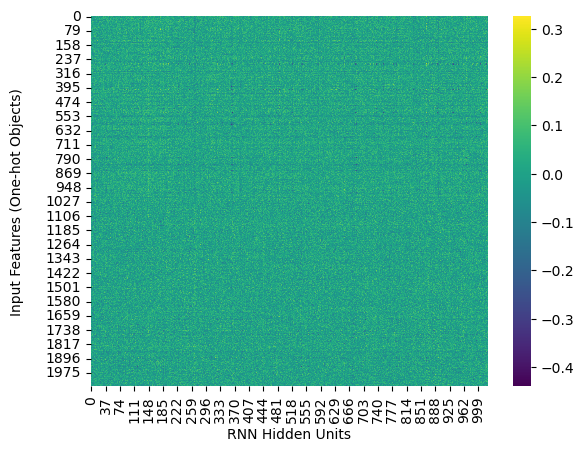

In [35]:
ax = sns.heatmap(model_weights['rnn.i2h.weight'].T, cmap='viridis')
ax.set_xlabel('RNN Hidden Units')
ax.set_ylabel('Input Features (One-hot Objects)\n  ')


Text(0.5, 1.0, 'First 3 Principal Components of Input-Hidden Weights')

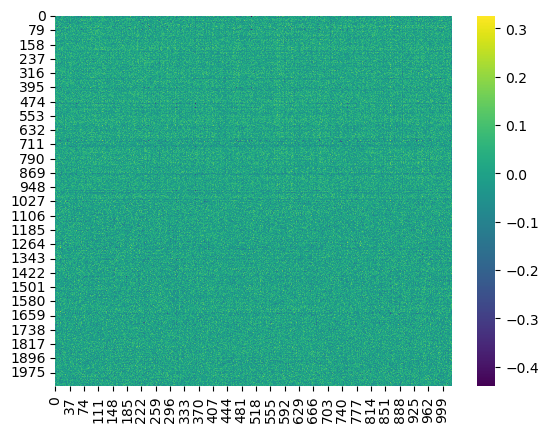

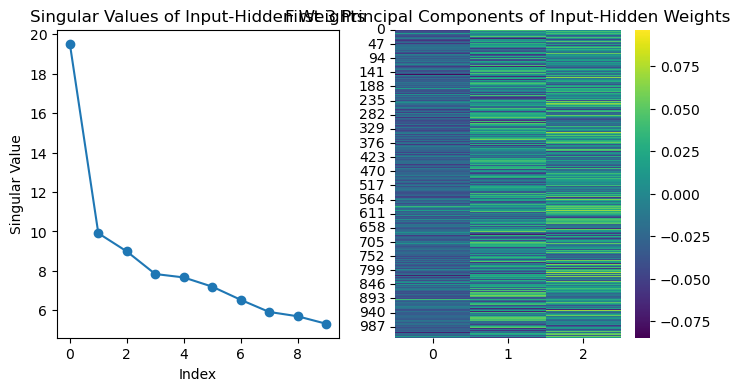

In [38]:
sns.heatmap(model_weights['rnn.i2h.weight'].T, cmap='viridis')
# perform svd on the input-hidden weights
U, S, Vt = np.linalg.svd(model_weights['rnn.i2h.weight'], full_matrices=False)
plt.figure(figsize=(8,4))
# plot the singular values (only first 10)
plt.subplot(1,2,1)
plt.plot(S[:10], marker='o')
plt.title('Singular Values of Input-Hidden Weights')
plt.xlabel('Index')
plt.ylabel('Singular Value')
# plot the first 3 PCs in heatmap
plt.subplot(1,2,2)
sns.heatmap(U[:,:3], cmap='viridis')
plt.title('First 3 Principal Components of Input-Hidden Weights')